## PROJECT: Fashion Item Classifier 👕👗👠
### Classify clothing items into 10 categories using deep learning!
### Categories: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
print("🛍️  FASHION ITEM CLASSIFIER")
print("=" * 60)

🛍️  FASHION ITEM CLASSIFIER


In [3]:
# Load Fashion MNIST dataset
print("\n📦 Loading fashion dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"✓ Training images: {len(x_train)}")
print(f"✓ Test images: {len(x_test)}")


📦 Loading fashion dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 34s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step
✓ Training images: 60000
✓ Test images: 10000


✓ Saved sample images


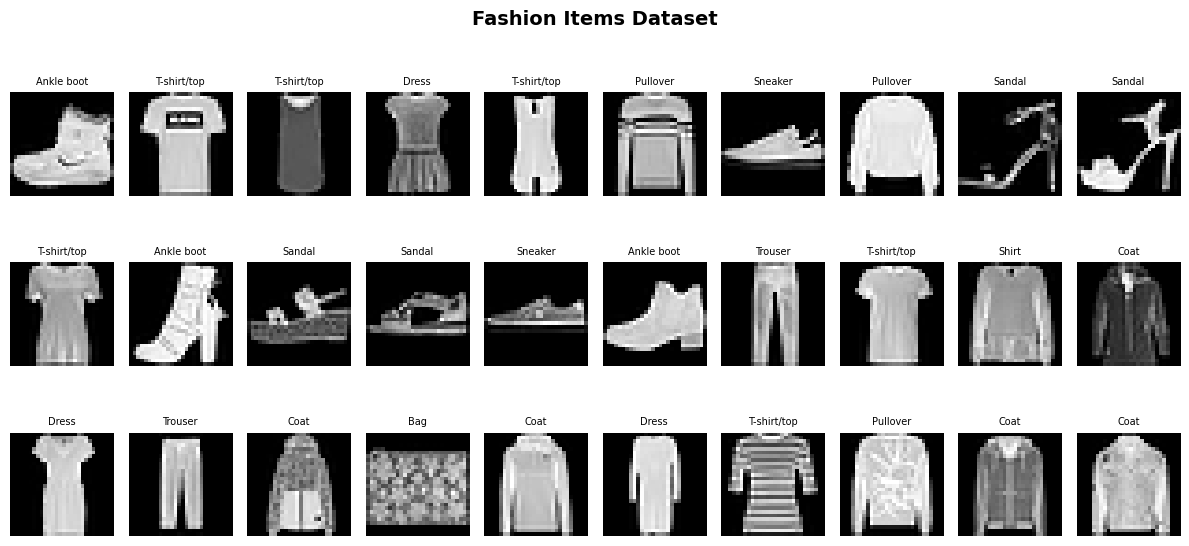

In [4]:
# Visualize samples
plt.figure(figsize=(12, 6))
for i in range(30):
    plt.subplot(3, 10, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=7)
    plt.axis('off')
plt.suptitle('Fashion Items Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fashion_samples.png', dpi=150, bbox_inches='tight')
print("✓ Saved sample images")

In [5]:
# Prepare data
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

In [6]:
# Build model
print("\n🧠 Building neural network...")
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model created")


🧠 Building neural network...


C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✓ Model created


In [7]:
# Train
print("\n🏋️  Training model...")
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


🏋️  Training model...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step - accuracy: 0.7707 - loss: 0.6438 - val_accuracy: 0.8429 - val_loss: 0.4383
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.8400 - loss: 0.4445 - val_accuracy: 0.8635 - val_loss: 0.3786
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8535 - loss: 0.4036 - val_accuracy: 0.8679 - val_loss: 0.3672
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.8626 - loss: 0.3765 - val_accuracy: 0.8652 - val_loss: 0.3624
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 52ms/step - accuracy: 0.8675 - loss: 0.3635 - val_accuracy: 0.8789 - val_loss: 0.3384
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.8739 - loss: 0.3464 - val_accuracy: 0.8820 - val_loss: 0.3266
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8781 - loss: 0.3341 - val_accuracy: 0.8808 - val_loss: 0.3278
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0

In [9]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n📊 Test Accuracy: {test_acc*100:.2f}%")


📊 Test Accuracy: 88.29%


✓ Saved predictions

🎉 Fashion classifier complete!
Can distinguish between 10 clothing types!


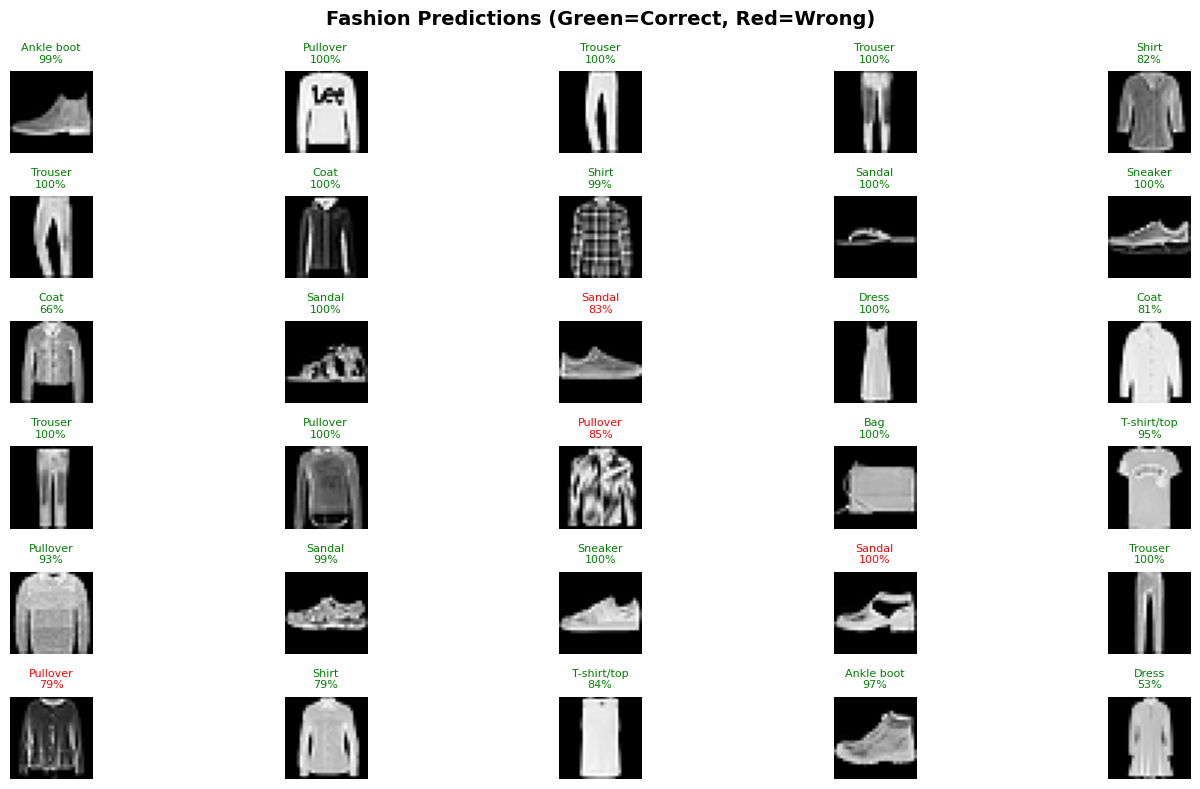

In [10]:
# Visualize predictions
predictions = model.predict(x_test[:30], verbose=0)

plt.figure(figsize=(15, 8))
for i in range(30):
    plt.subplot(6, 5, i+1)
    img = x_test[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    
    pred_idx = np.argmax(predictions[i])
    true_idx = y_test[i]
    
    color = 'green' if pred_idx == true_idx else 'red'
    confidence = predictions[i][pred_idx] * 100
    
    plt.title(f'{class_names[pred_idx]}\n{confidence:.0f}%', 
              color=color, fontsize=8)
    plt.axis('off')

plt.suptitle('Fashion Predictions (Green=Correct, Red=Wrong)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fashion_predictions.png', dpi=150, bbox_inches='tight')
print("✓ Saved predictions")

print("\n🎉 Fashion classifier complete!")
print(f"Can distinguish between {len(class_names)} clothing types!")